### IMPORTS

In [1]:
import warnings
# Ignore all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

import re
import math
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.svm import SVC
import random
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

# Make results reproducible
random.seed(100)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\UFC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Load Data

In [2]:
# Labelled data loading
data = pd.read_csv('A2_customer_churn_labeled.csv')
data.head()

,ID,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,customer_profile,Y
0,0,585,4,0.00,2,0,1,101728.46,This customer is a 44-year-old female from Spa...,0
1,1,743,6,140348.56,2,1,1,163254.39,This customer is a 32-year-old female from Ger...,0
2,2,527,10,136733.23,1,1,1,57589.29,This customer is a 41-year-old female from Ger...,0
3,3,732,6,98792.40,1,1,0,81491.70,This customer is a 45-year-old female from Ger...,1
4,4,641,3,0.00,2,1,0,116466.19,This customer is a 38-year-old female from Fra...,0


In [3]:
print('Shape of labeled data: ', data.shape)

Shape of labeled data:  (7000, 10)


### Helper functions for adding new columns 

In [4]:
def get_last_two_sentences(text):
    sentences = sent_tokenize(text)

    # Get the last 2 sentences
    last_two_sentences = sentences[-2:]

    return ' '.join(last_two_sentences)

# Create an object instance sih of SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Function that returns compound polarity score of the text
def get_polarity(text):
    # Get the polarity scores of the passed text
    return sia.polarity_scores(text)['compound']

# Load spaCy's English tokenizer and tagger
nlp = spacy.load("en_core_web_sm")

# Define a function to perform tokenization, stopwords removal, and lemmatization
def preprocess_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.text.lower() not in STOP_WORDS]
    return " ".join(tokens)


### Add new columns

In [5]:
def add_new_columns(dataset):
     #  Just comment the line for the column that is not needed
    
    dataset['age'] = dataset['customer_profile'].apply(lambda x: int(re.findall('(\d+)-year-old', x)[0]))
    dataset['gender'] = dataset['customer_profile'].apply(lambda x: re.findall('(male|female)', x)[0])
    dataset['country'] = dataset['customer_profile'].apply(lambda x: re.findall('from (\w+)', x)[0])
    dataset['last_lines'] = dataset['customer_profile'].apply(lambda text: get_last_two_sentences(text))
    dataset['customer_profile_polarity'] = dataset['customer_profile'].apply(lambda text: get_polarity(text))
    dataset['last_lines_polarity'] = dataset['last_lines'].apply(lambda text: get_polarity(text))
    dataset['customer_profile_tokenized'] = dataset['customer_profile'].apply(lambda text: preprocess_text(text))
    return dataset

In [6]:
data1 = add_new_columns(data)

### Drop any existing columns

In [7]:
def drop_any_existing_columns(dataset, columns = ['ID']):
    dataset = dataset.drop(columns=columns, inplace=False)
    return dataset

In [8]:
columns_to_drop = ['ID', 'customer_profile', 'last_lines', 'customer_profile_tokenized']

data2 = drop_any_existing_columns(data1, columns = columns_to_drop)

### Any required feature transformations

In [9]:
data2.head()

,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,Y,age,gender,country,customer_profile_polarity,last_lines_polarity
0,585,4,0.00,2,0,1,101728.46,0,44,female,Spain,0.7311,0.4512
1,743,6,140348.56,2,1,1,163254.39,0,32,female,Germany,0.7845,0.6486
2,527,10,136733.23,1,1,1,57589.29,0,41,female,Germany,0.7845,0.6486
3,732,6,98792.40,1,1,0,81491.70,1,45,female,Germany,0.4482,-0.3089
4,641,3,0.00,2,1,0,116466.19,0,38,female,France,0.4482,-0.3089


In [10]:
### Dummy variablize
data3 = pd.get_dummies(data2, columns = ['gender', 'country'], drop_first=True )
print(data3.columns)
data3.head()

Index(['credit_score', 'tenure', 'balance', 'number_of_products',
       'has_credit_card', 'is_active_member', 'salary', 'Y', 'age',
       'customer_profile_polarity', 'last_lines_polarity', 'gender_male',
       'country_Germany', 'country_Spain'],
      dtype='object')


,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,Y,age,customer_profile_polarity,last_lines_polarity,gender_male,country_Germany,country_Spain
0,585,4,0.00,2,0,1,101728.46,0,44,0.7311,0.4512,False,False,True
1,743,6,140348.56,2,1,1,163254.39,0,32,0.7845,0.6486,False,True,False
2,527,10,136733.23,1,1,1,57589.29,0,41,0.7845,0.6486,False,True,False
3,732,6,98792.40,1,1,0,81491.70,1,45,0.4482,-0.3089,False,True,False
4,641,3,0.00,2,1,0,116466.19,0,38,0.4482,-0.3089,False,False,False


In [11]:
data3.head()

,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,Y,age,customer_profile_polarity,last_lines_polarity,gender_male,country_Germany,country_Spain
0,585,4,0.00,2,0,1,101728.46,0,44,0.7311,0.4512,False,False,True
1,743,6,140348.56,2,1,1,163254.39,0,32,0.7845,0.6486,False,True,False
2,527,10,136733.23,1,1,1,57589.29,0,41,0.7845,0.6486,False,True,False
3,732,6,98792.40,1,1,0,81491.70,1,45,0.4482,-0.3089,False,True,False
4,641,3,0.00,2,1,0,116466.19,0,38,0.4482,-0.3089,False,False,False


## Models implementation

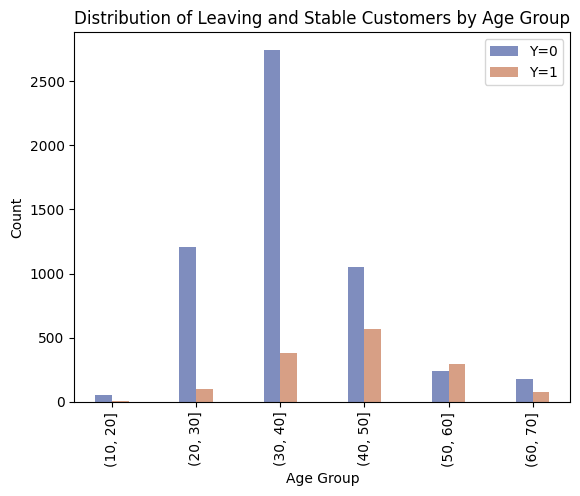

In [15]:
age_bins = [10, 20, 30, 40, 50, 60, 70]

# Create age groups using pd.cut
data3['age_group'] = pd.cut(data3['age'], bins=age_bins)

# Group by age group and Y, and count occurrences
age_group_counts = data3.groupby(['age_group', 'Y']).size().unstack(fill_value=0)

# Plot the counts of leaving (1) and stable (0) customers by age group
age_group_counts.plot(kind='bar', width=0.4, color=['#7f8dbe','#d79f85'])
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Distribution of Leaving and Stable Customers by Age Group')
plt.legend(labels=['Y=0', 'Y=1'])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assuming you have already fitted the linear regression model (lin_price)

# Calculate residuals and leverage values
influence = lin_price.get_influence()
residuals = lin_price.resid
leverage = influence.hat_matrix_diag


# Create a residual leverage plot
fig, ax = plt.subplots(figsize=(10, 6))
sm.graphics.plot_leverage_resid2(lin_price, ax=ax)

# Customize the plot
plt.title('Residual vs. Leverage Plot')
plt.xlabel('Leverage')
plt.ylabel('Standardized Residuals')
plt.grid(True)

# Show the plot
plt.show()


### Model evaluation metrics

In [38]:
def calc_f1_score(model, X=None, y=None, dataset=None, type='macro'):
    if X is None and y is None and dataset is not None:
        y = dataset['Y']
        X = dataset.drop(columns='Y')
    y_pred = model.predict(X)
    return f1_score(y, y_pred, average='macro')

### Model 1 Random Forest Basic

In [48]:
# Perform train test split
X_train, X_test, y_train, y_test = train_test_split(data3.drop(columns='Y'), data3['Y'], test_size=0.2, random_state=42)

In [49]:
from sklearn.ensemble import RandomForestClassifier

# Create and fit the RandomForestRegressor
bag_classifier = RandomForestClassifier(n_estimators=500, random_state=1)
bag_classifier.fit(X_train, y_train)



RandomForestClassifier(n_estimators=500, random_state=1)

In [50]:
calc_f1_score(bag_classifier, X=X_test, y=y_test)

0.7120606254770974

In [51]:
bag_classifier.fit(data3.drop(columns='Y'), data3['Y'])

RandomForestClassifier(n_estimators=500, random_state=1)

### Model 2 Random Forest with hyperparameter tuning

In [62]:
n_estimators_choices = [100, 500, 1000]
max_features_choices = [5, 10, 'ALL']

from sklearn.ensemble import RandomForestClassifier
from itertools import product

grid = product(n_estimators_choices, max_features_choices)
np.random.seed(1)

best_hyperparameters = None
best_score = -math.inf
best_model = None

for n_est, max_fts in grid:
    print('Training for n_estimators = {} and max_features = {}'.format(n_est, max_fts))
    if max_fts == 'ALL':
        # Create and fit the RandomForestClassifier
        bag_classifier_hyp = RandomForestClassifier(n_estimators=n_est, random_state=1)
    else:
        # Create and fit the RandomForestClassifier
        bag_classifier_hyp = RandomForestClassifier(n_estimators=n_est, max_features=max_fts, random_state=1)
    
    bag_classifier_hyp.fit(X_train, y_train)
    
    # Calculate the F1
    f1_bag_hyp = calc_f1_score(bag_classifier_hyp, X=X_test, y=y_test)
    
    print("\tF1 Score:", f1_bag_hyp)

    if f1_bag_hyp > best_score:
        best_score = f1_bag_hyp
        best_hyperparameters = (n_est, max_fts)
        best_model = bag_classifier_hyp
        

Training for n_estimators = 100 and max_features = 5
	F1 Score: 0.7079445545175062
Training for n_estimators = 100 and max_features = 10
	F1 Score: 0.712779407905723
Training for n_estimators = 100 and max_features = ALL
	F1 Score: 0.7050598117534764
Training for n_estimators = 500 and max_features = 5
	F1 Score: 0.7120606254770974
Training for n_estimators = 500 and max_features = 10
	F1 Score: 0.7079741886863549
Training for n_estimators = 500 and max_features = ALL
	F1 Score: 0.7120606254770974
Training for n_estimators = 1000 and max_features = 5
	F1 Score: 0.7170052006672554
Training for n_estimators = 1000 and max_features = 10
	F1 Score: 0.7125411135289896
Training for n_estimators = 1000 and max_features = ALL
	F1 Score: 0.7117768687510628


In [63]:
best_hyperparameters

(1000, 5)

### Model 3 Random Forest basic with sampling methods

In [39]:
from imblearn.over_sampling import SMOTE
import pandas as pd

def sampling_methods(X,sampling_method,sampling_ratio = None):
    
    minority_class_label = 1
    
    if sampling_method == 'over':

        minority_samples = X[X['Y'] == minority_class_label]
        majority_samples = X[X['Y'] != minority_class_label]
        
        if sampling_ratio == None:
            ratio = len(majority_samples) // len(minority_samples)
        else:
            ratio = sampling_ratio
        oversampled_minority = minority_samples.sample(n=len(minority_samples) * (ratio), replace=True)

        df = pd.concat([majority_samples, oversampled_minority], ignore_index=True)
    
    elif sampling_method == 'under':

        minority_samples = X[X['Y'] == minority_class_label]
        majority_samples = X[X['Y'] != minority_class_label]

        if sampling_ratio == None:
            ratio = len(minority_samples) / len(majority_samples)
        else:
            ratio = sampling_ratio
        
        undersampled_majority = majority_samples.sample(frac=ratio, random_state= 42)

        df = pd.concat([minority_samples, undersampled_majority], ignore_index=True)
    
    elif sampling_method == 'SMOTE':
        
        minority_samples = X[X['Y'] == minority_class_label]
        majority_samples = X[X['Y'] != minority_class_label]

        if sampling_ratio == None:
            ratio = 'auto'
        else:
            ratio = sampling_ratio
        

        features = X.drop(columns=['Y'])
        label = X['Y']
        
        smote = SMOTE(sampling_strategy= ratio, random_state=42)
        X_resampled, y_resampled = smote.fit_resample(features, label)
        
        df = pd.concat([pd.DataFrame(X_resampled, columns=features.columns),
                                  pd.Series(y_resampled, name='Y')], axis=1)

    return df

In [40]:
data3_smote = sampling_methods(data3, 'SMOTE')

In [41]:
data3_smote['Y'].value_counts()

Y
0    5565
1    5565
Name: count, dtype: int64

In [42]:
data3_smote

,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,age,customer_profile_polarity,last_lines_polarity,gender_male,country_Germany,country_Spain,Y
0,585,4,0.000000,2,0,1,101728.460000,44,0.731100,0.451200,False,False,True,0
1,743,6,140348.560000,2,1,1,163254.390000,32,0.784500,0.648600,False,True,False,0
2,527,10,136733.230000,1,1,1,57589.290000,41,0.784500,0.648600,False,True,False,0
3,732,6,98792.400000,1,1,0,81491.700000,45,0.448200,-0.308900,False,True,False,1
4,641,3,0.000000,2,1,0,116466.190000,38,0.448200,-0.308900,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11125,660,2,133801.451833,1,1,0,55169.030495,29,0.253300,-0.239486,True,True,True,1
11126,756,4,139700.244658,3,0,0,129781.145544,44,0.725547,0.058447,True,True,False,1
11127,521,7,74988.974295,2,0,0,103316.631333,48,0.660026,0.211109,True,True,False,1
11128,702,3,204362.517259,2,0,1,132481.863149,36,0.800655,0.485759,False,False,True,1


In [83]:
# Perform train test split
X_train, X_test, y_train, y_test = train_test_split(data3_smote.drop(columns='Y'), data3_smote['Y'], test_size=0.2, random_state=42)

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

In [56]:
p_f1_scores = []

X = data3_smote.drop(columns='Y')
y = data3_smote['Y']

for p in range(2, 8):
    print(p, end=' ')
    # Create and fit the RandomForestRegressor
    bag_classifier = make_pipeline(PolynomialFeatures(p), RandomForestClassifier(n_estimators=1000, random_state=1))
    # Define the F1 scorer to use with cross_val_score
    f1_scorer = make_scorer(f1_score)

    # Perform cross-validation and calculate F1 scores
    f1_scores = cross_val_score(bag_classifier, X, y, cv=10, scoring=f1_scorer)
    print('Mean f1 score:', f1_scores.mean())
    p_f1_scores.append(f1_scores) 
    
    
    
    

2 Mean f1 score: 0.8824711741482704
3 Mean f1 score: 0.8799703752013673
4 Mean f1 score: 0.8789893373672324
5 Mean f1 score: 0.8802813792753537
6 

KeyboardInterrupt: 

In [86]:
calc_f1_score(bag_classifier, X=X_test, y=y_test)

0.893440137867207

In [58]:
bag_classifier = make_pipeline(PolynomialFeatures(5), RandomForestClassifier(n_estimators=1000, random_state=1))

In [59]:
bag_classifier.fit(data3_smote.drop(columns='Y'), data3_smote['Y'])

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=5)),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=1000, random_state=1))])

### Generating the Kaggle Submission File

In [60]:
final_model = bag_classifier

In [62]:
X_kaggle_test = pd.read_csv('A2_customer_churn_kaggle.csv')

In [63]:
# Add columns
X_kaggle_test1 = add_new_columns(X_kaggle_test)

In [64]:
# Drop columns
columns_to_drop = ['ID', 'Y', 'customer_profile', 'last_lines', 'customer_profile_tokenized']
X_kaggle_test1 = drop_any_existing_columns(X_kaggle_test1, columns = columns_to_drop)

In [65]:
### Dummy variablize
X_kaggle_test1 = pd.get_dummies(X_kaggle_test1, columns = ['gender', 'country'], drop_first=True )

In [66]:
print('Shape of kaggle test: ', X_kaggle_test1.shape)
X_kaggle_test1.head()

Shape of kaggle test:  (2010, 13)


,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,age,customer_profile_polarity,last_lines_polarity,gender_male,country_Germany,country_Spain
0,652,4,59486.31,1,1,0,163944.19,48,0.4482,-0.3089,True,False,False
1,714,4,0.00,2,1,1,37605.90,29,0.7845,0.6486,True,False,True
2,733,3,100337.96,3,1,0,48559.19,34,0.4482,-0.3089,True,True,False
3,577,8,79757.21,1,1,0,135650.72,43,0.4482,-0.3089,True,False,True
4,600,2,119755.00,1,1,1,21852.91,30,0.7845,0.6486,True,True,False


In [67]:
y_pred = final_model.predict(X_kaggle_test1)
df_pred = pd.concat([X_kaggle_test['ID'], pd.DataFrame(y_pred,columns=['Y'])], axis = 1)
df_pred.to_csv('kaggle_pred_values.csv',index=False)